In [ ]:
Groups = { 'Large', 'Medium', 'Small' }
Demand = { 'Large' : 120, 'Medium' : 180, 'Small' : 150 }
Suppliers = { 'Supplier 1', 'Supplier 2', 'Supplier 3', 'Supplier 4', 'Supplier 5' }
Cost = { 'Supplier 1': 310, 'Supplier 2': 270, 'Supplier 3': 320, 'Supplier 4': 240, 'Supplier 5': 250 }
Content = {
    ('Supplier 1', 'Large') : 0.28, 	('Supplier 1', 'Medium') : 0.45, 	('Supplier 1', 'Small') : 0.27, 
    ('Supplier 2', 'Large') : 0.25, 	('Supplier 2', 'Medium') : 0.4, 	('Supplier 2', 'Small') : 0.35, 
    ('Supplier 3', 'Large') : 0.3, 	('Supplier 3', 'Medium') : 0.41, 	('Supplier 3', 'Small') : 0.29, 
    ('Supplier 4', 'Large') : 0.17, 	('Supplier 4', 'Medium') : 0.48, 	('Supplier 4', 'Small') : 0.35, 
    ('Supplier 5', 'Large') : 0.21, 	('Supplier 5', 'Medium') : 0.42, 	('Supplier 5', 'Small') : 0.37
}

## Ohadi Foods – Linear Programming Model Summary

### Sets
- \( S \): Suppliers  
- \( P \): Product Groups (Large, Medium, Small)

### Parameters
- \( c_s \): Cost per tonne from supplier \( s \)  
- \( a_{sp} \): Proportion of group \( p \) in supplier \( s \)'s shipment  
- \( d_p \): Demand for group \( p \)

### Decision Variables
- \( x_s \): Tonnes to purchase from supplier \( s \)

### Objective
- Minimize total cost:  
  \[
  \min \sum_{s \in S} c_s x_s
  \]

### Constraints
- Meet demand for each group:  
  \[
  \sum_{s \in S} a_{sp} x_s \geq d_p \quad \forall p \in P
  \]  
- Non-negativity: \( x_s \geq 0 \)

### Solver Output
Optimal solution found \& Total Cost is \$129,046.15.

In [2]:
import gurobipy as gp
from gurobipy import GRB

# Sets
Suppliers = ['Supplier 1', 'Supplier 2', 'Supplier 3', 'Supplier 4', 'Supplier 5']
Groups = ['Large', 'Medium', 'Small']

# Parameters
Demand = {'Large': 120, 'Medium': 180, 'Small': 150}

Cost = {
    'Supplier 1': 310, 'Supplier 2': 270, 'Supplier 3': 320,
    'Supplier 4': 240, 'Supplier 5': 250
}

Content = {
    ('Supplier 1', 'Large'): 0.28, ('Supplier 1', 'Medium'): 0.45, ('Supplier 1', 'Small'): 0.27,
    ('Supplier 2', 'Large'): 0.25, ('Supplier 2', 'Medium'): 0.40, ('Supplier 2', 'Small'): 0.35,
    ('Supplier 3', 'Large'): 0.30, ('Supplier 3', 'Medium'): 0.41, ('Supplier 3', 'Small'): 0.29,
    ('Supplier 4', 'Large'): 0.17, ('Supplier 4', 'Medium'): 0.48, ('Supplier 4', 'Small'): 0.35,
    ('Supplier 5', 'Large'): 0.21, ('Supplier 5', 'Medium'): 0.42, ('Supplier 5', 'Small'): 0.37
}

# Model
model = gp.Model("Ohadi_Foods_Supply")

# Decision Variables: x_s = amount purchased from supplier s (in tonnes)
x = model.addVars(Suppliers, name="x", lb=0.0)

# Objective: Minimize total purchasing cost
model.setObjective(gp.quicksum(Cost[s] * x[s] for s in Suppliers), GRB.MINIMIZE)

# Constraints: For each group (Large, Medium, Small), meet demand
for g in Groups:
    model.addConstr(gp.quicksum(Content[s, g] * x[s] for s in Suppliers) >= Demand[g],
                    name=f"Demand_{g}")

# Optimize
model.optimize()

# Output Results
# if model.status == GRB.OPTIMAL:
#     print("\nOptimal Solution:")
#     for s in Suppliers:
#         print(f"Purchase from {s}: {x[s].X:.2f} tonnes")
#     print(f"\nTotal Cost: ${model.ObjVal:.2f}")
# else:
#     print("Model did not solve to optimality.")

print("\nOptimal Solution:")
for s in Suppliers:
    if x[s].X > 1e-6:
        print(f"  Purchase from {s}: {x[s].X:.2f} tonnes")
print(f"\nTotal Cost: ${model.ObjVal:,.2f}")

# Basic sanity check
assert model.status == GRB.OPTIMAL, "Model did not solve to optimality!"
assert all(x[s].X >= 0 for s in Suppliers), "Negative purchase amount detected!"

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Max
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 3 rows, 5 columns and 15 nonzeros
Model fingerprint: 0x1a293d7c
Coefficient statistics:
  Matrix range     [2e-01, 5e-01]
  Objective range  [2e+02, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 2e+02]
Presolve time: 0.01s
Presolved: 3 rows, 5 columns, 15 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   9.000000e+02   0.000000e+00      0s
       4    1.2904615e+05   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.290461538e+05

Optimal Solution:
  Purchase from Supplier 2: 313.85 tonnes
  Purchase from Supplier 3: 138.46 tonnes

Total Cost: $129,046.15


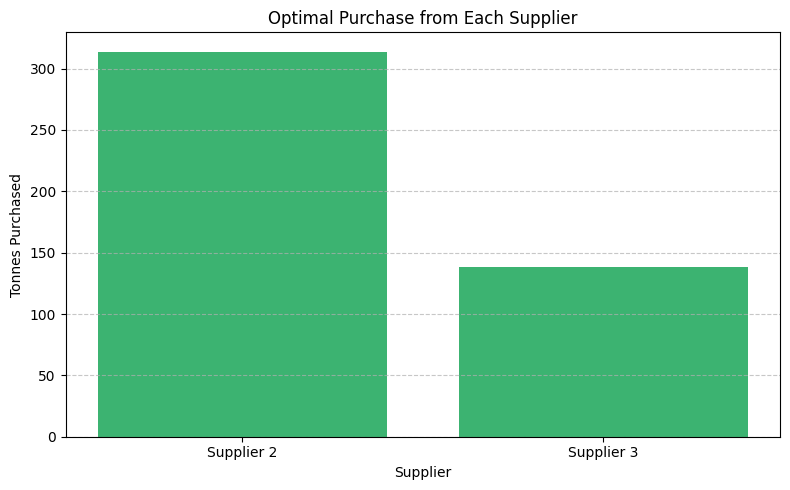

In [5]:
## Optional Save Results
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Supplier": Suppliers,
    "Purchase (tonnes)": [x[s].X for s in Suppliers]
})
results.to_csv("ohadi_solution.csv", index=False)

# Prepare data
supplier_names = [s for s in Suppliers if x[s].X > 1e-6]
purchased_amounts = [x[s].X for s in supplier_names]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(supplier_names, purchased_amounts, color='mediumseagreen')
plt.title("Optimal Purchase from Each Supplier")
plt.ylabel("Tonnes Purchased")
plt.xlabel("Supplier")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()